In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('ticks',
              rc={'axes.facecolor': (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['figure.dpi'] = 150

In [2]:
import numpy as np
import pandas as pd

In [3]:
# read chibio
m = pd.read_csv('data/pOXA48/chibio.tsv.gz', sep='\t')
# read plate counts
c = pd.read_csv('data/pOXA48/plate_counts.tsv', sep='\t')
# read plate reader fluorescence
p = pd.read_csv('data/pOXA48/plate_reader_fluorescence.tsv', sep='\t')
# read flow cytometer
f = pd.read_csv('data/pOXA48/flow_cytometer.tsv', sep='\t')

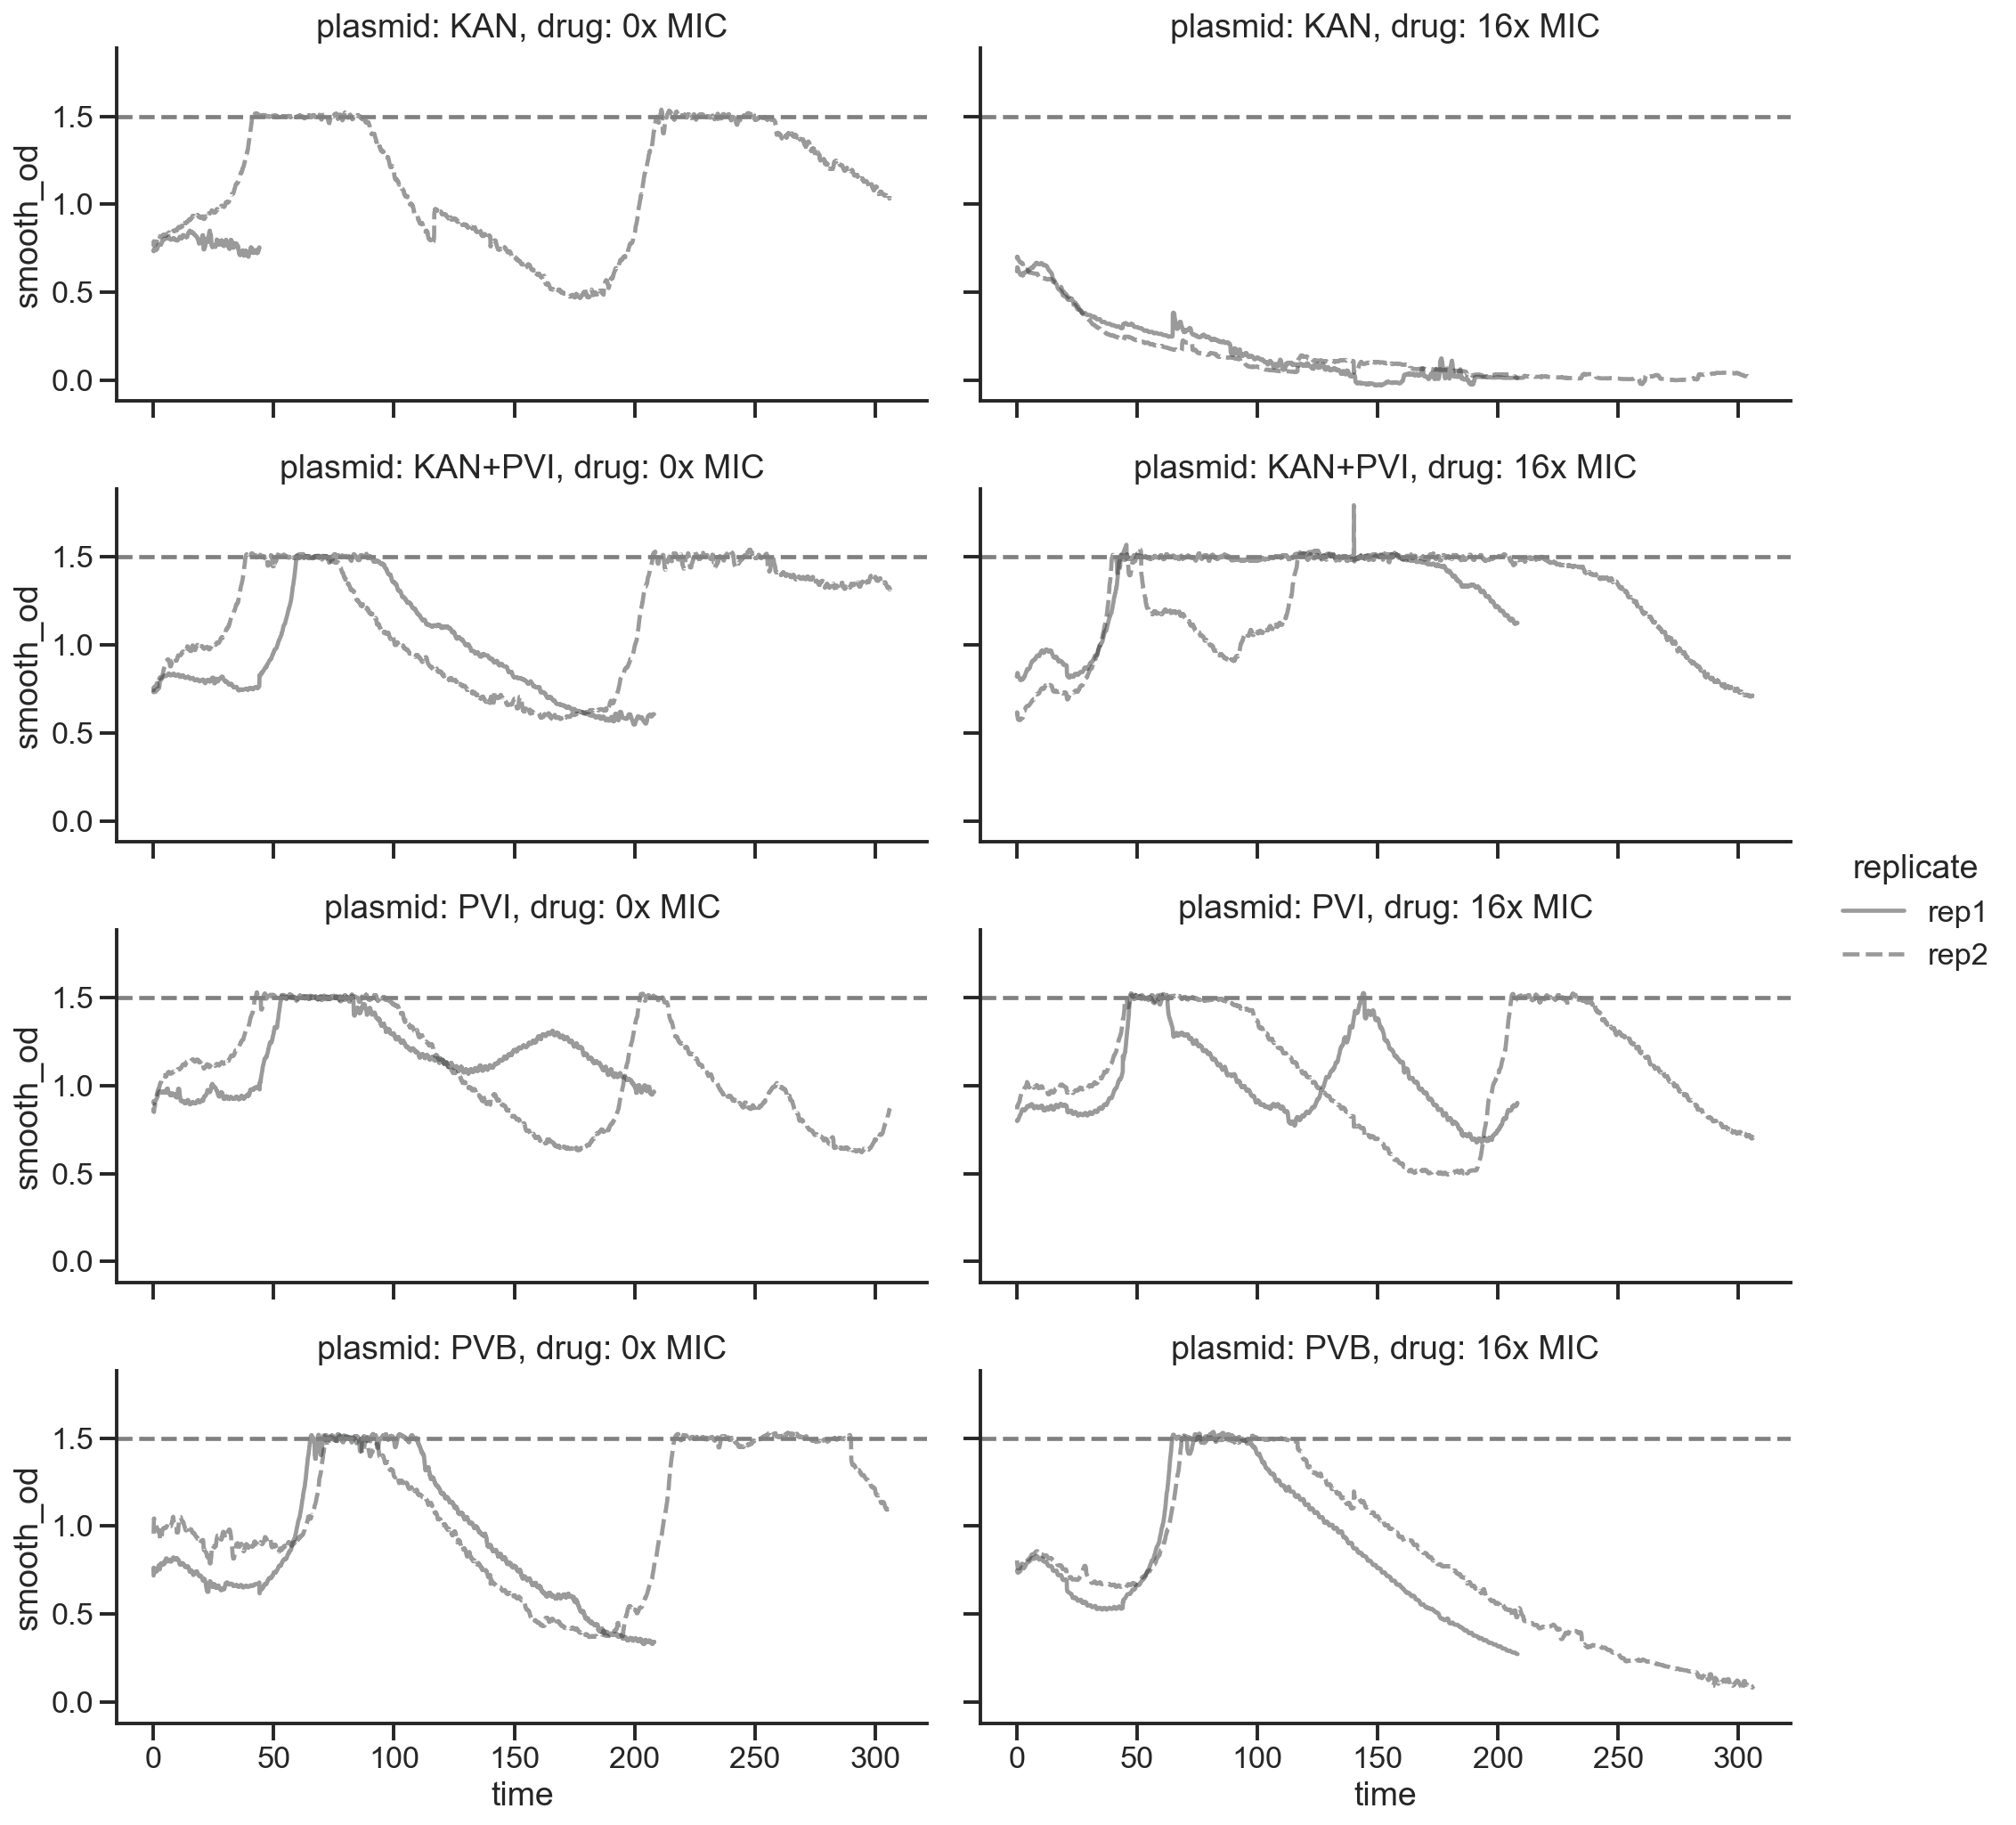

In [4]:
cp = sns.relplot(data=m,
                 x='time',
                 y='smooth_od',
                 col='drug',
                 style='replicate',
                 row='plasmid',
                 kind='line',
                 height=3.5, aspect=2,
                 color='xkcd:dark grey',
                 alpha=0.5,
                )

# cp.set(yscale='log')
cp.set_titles("plasmid: {row_name}, drug: {col_name}x MIC")
cp.map(plt.axhline, y=1.5, color='grey', linestyle='--');

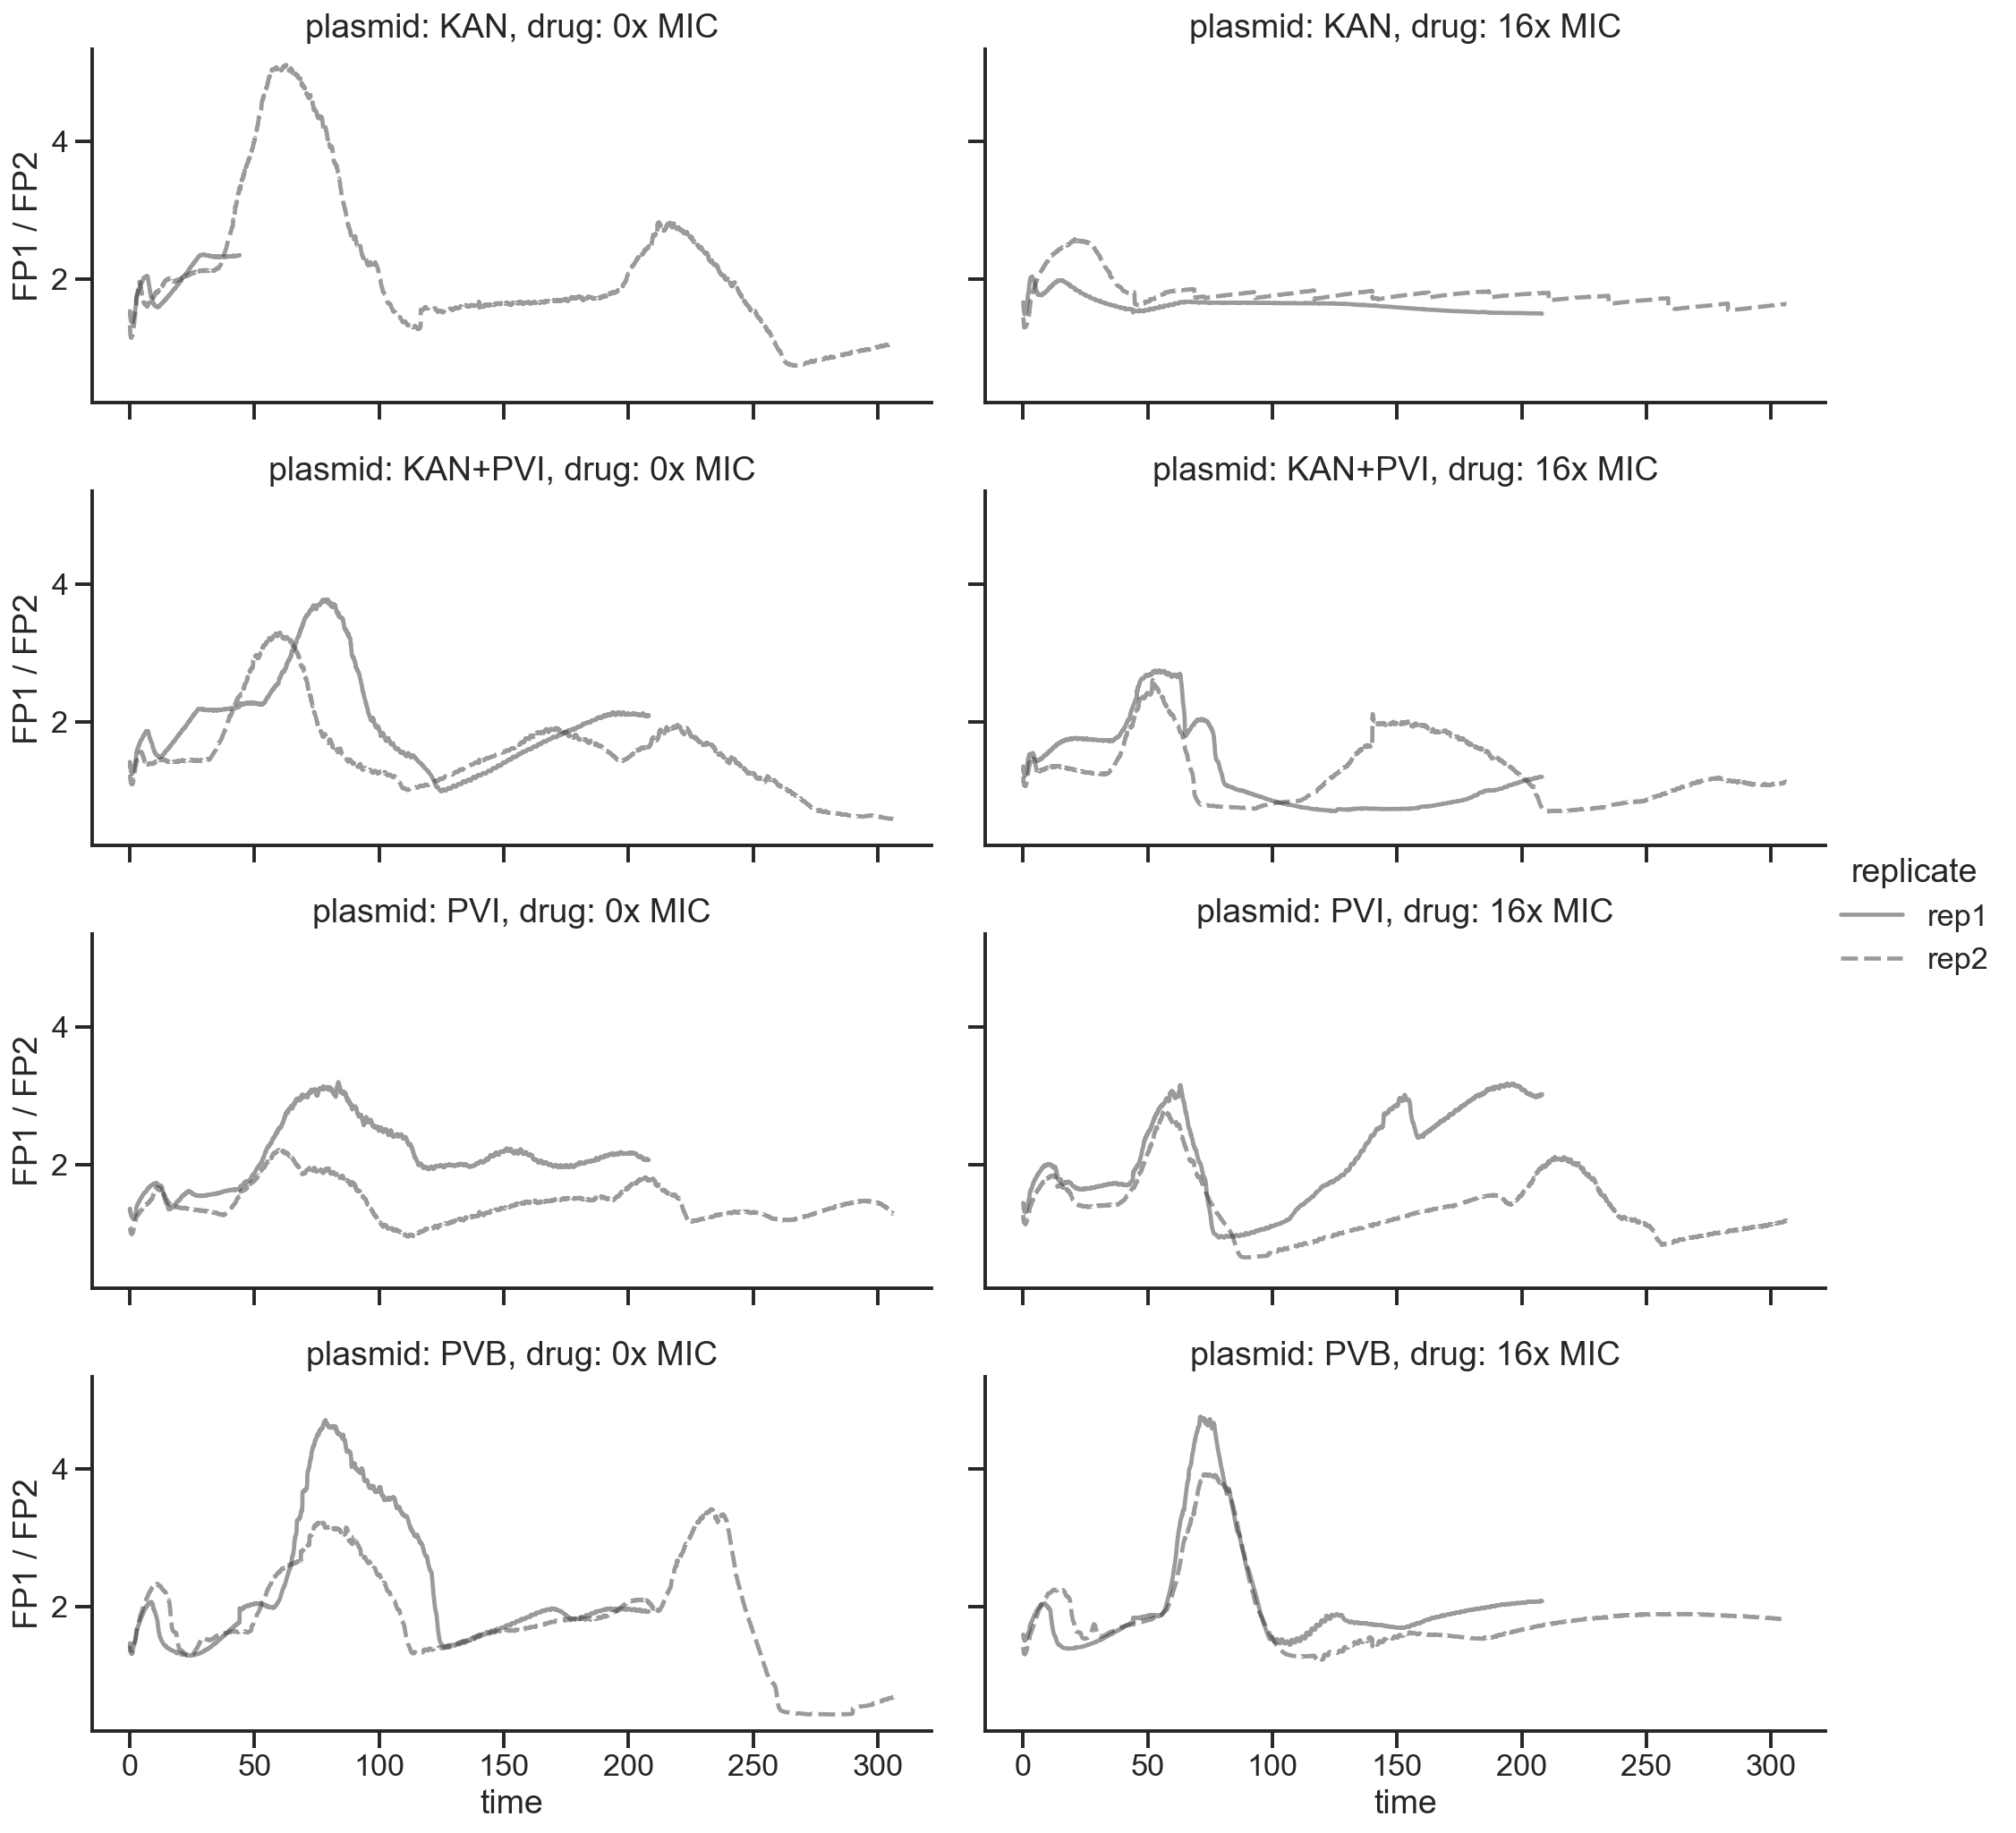

In [5]:
cp = sns.relplot(data=m,
                 x='time',
                 y='smooth_FP1_emit1_FP2_emit1_ratio',
                 col='drug',
                 style='replicate',
                 row='plasmid',
                 kind='line',
                 height=3.5, aspect=2,
                 color='xkcd:dark grey',
                 alpha=0.5,
                )

# cp.set(yscale='log')
cp.set_titles("plasmid: {row_name}, drug: {col_name}x MIC")
cp.set(ylabel='FP1 / FP2');

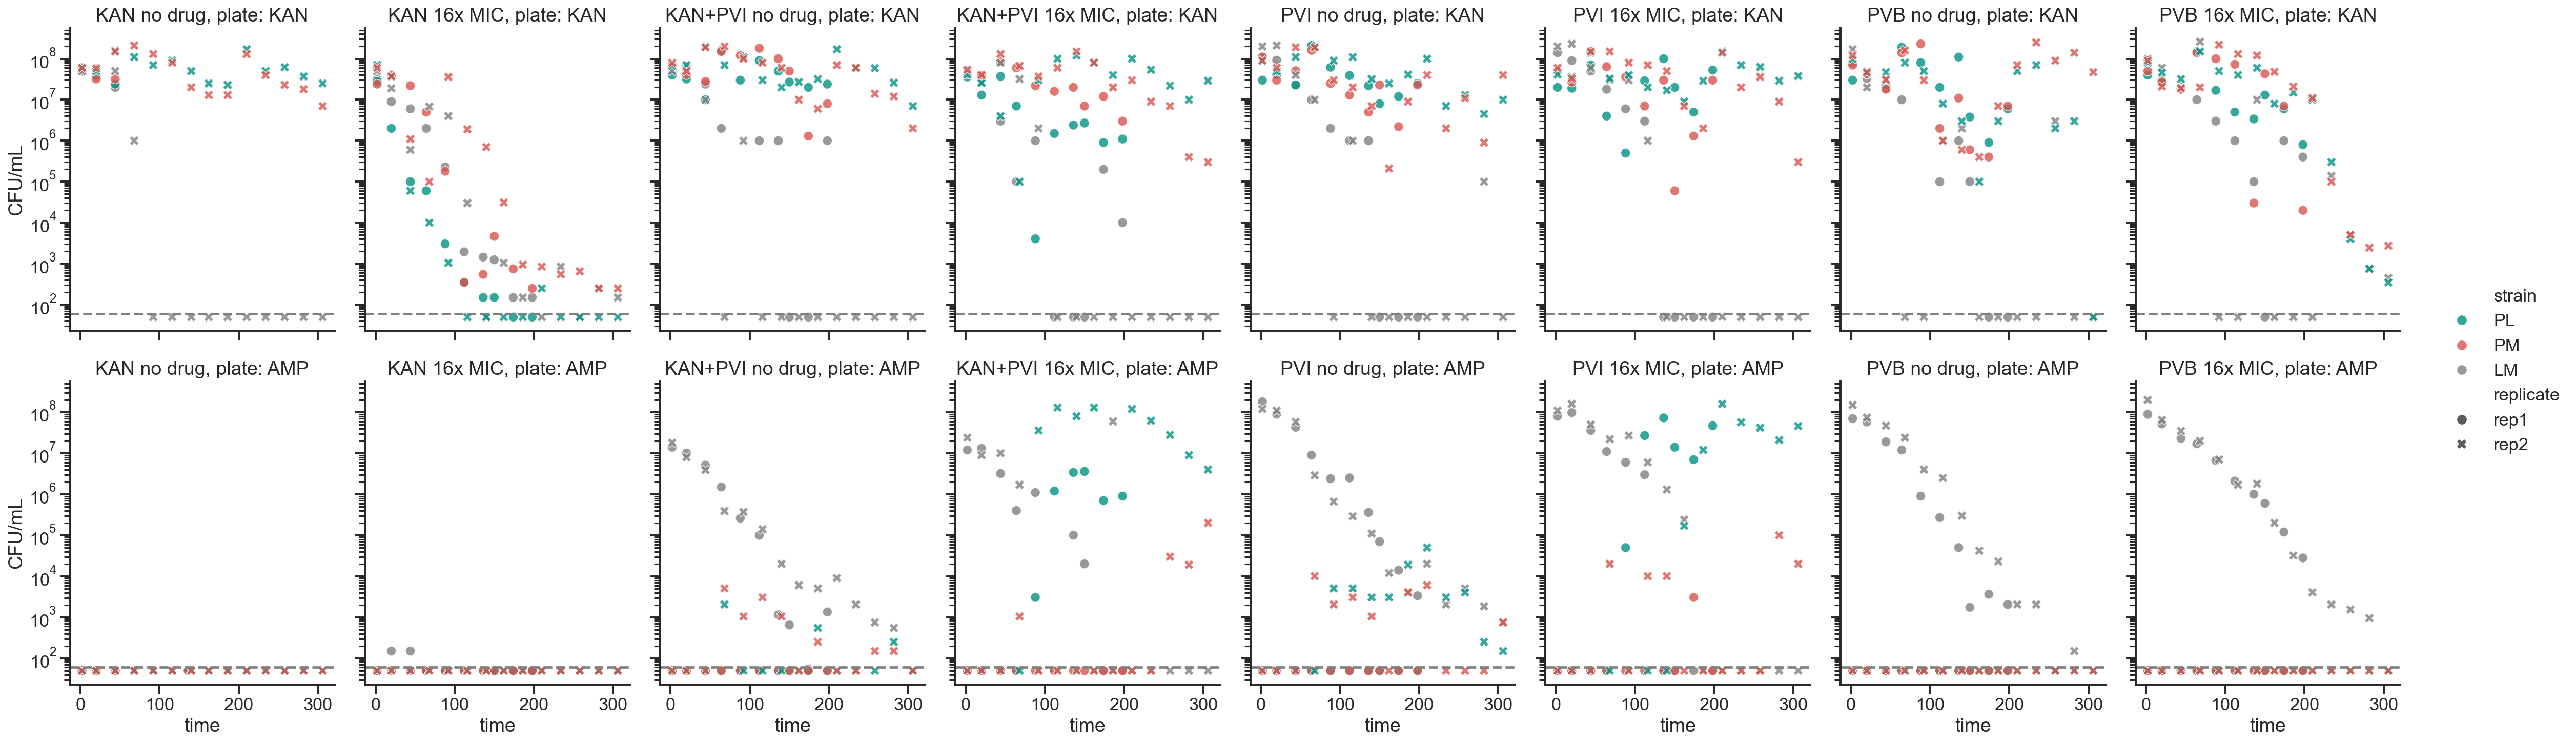

In [6]:
cp = sns.relplot(data=c,
                 x='time',
                 y='CFU/mL',
                 hue='strain',
                 col='short',
                 style='replicate',
                 row_order=['KAN', 'AMP'],
                 row='plate',
                 height=5, aspect=0.8,
                 alpha=0.8,
                 palette=['xkcd:teal',
                          'xkcd:pale red',
                          'grey'],
                 hue_order=['PL', 'PM', 'LM'])

cp.set(yscale='log')
cp.set_titles("{col_name}, plate: {row_name}")
cp.map(plt.axhline, y=60, color='grey', linestyle='--');

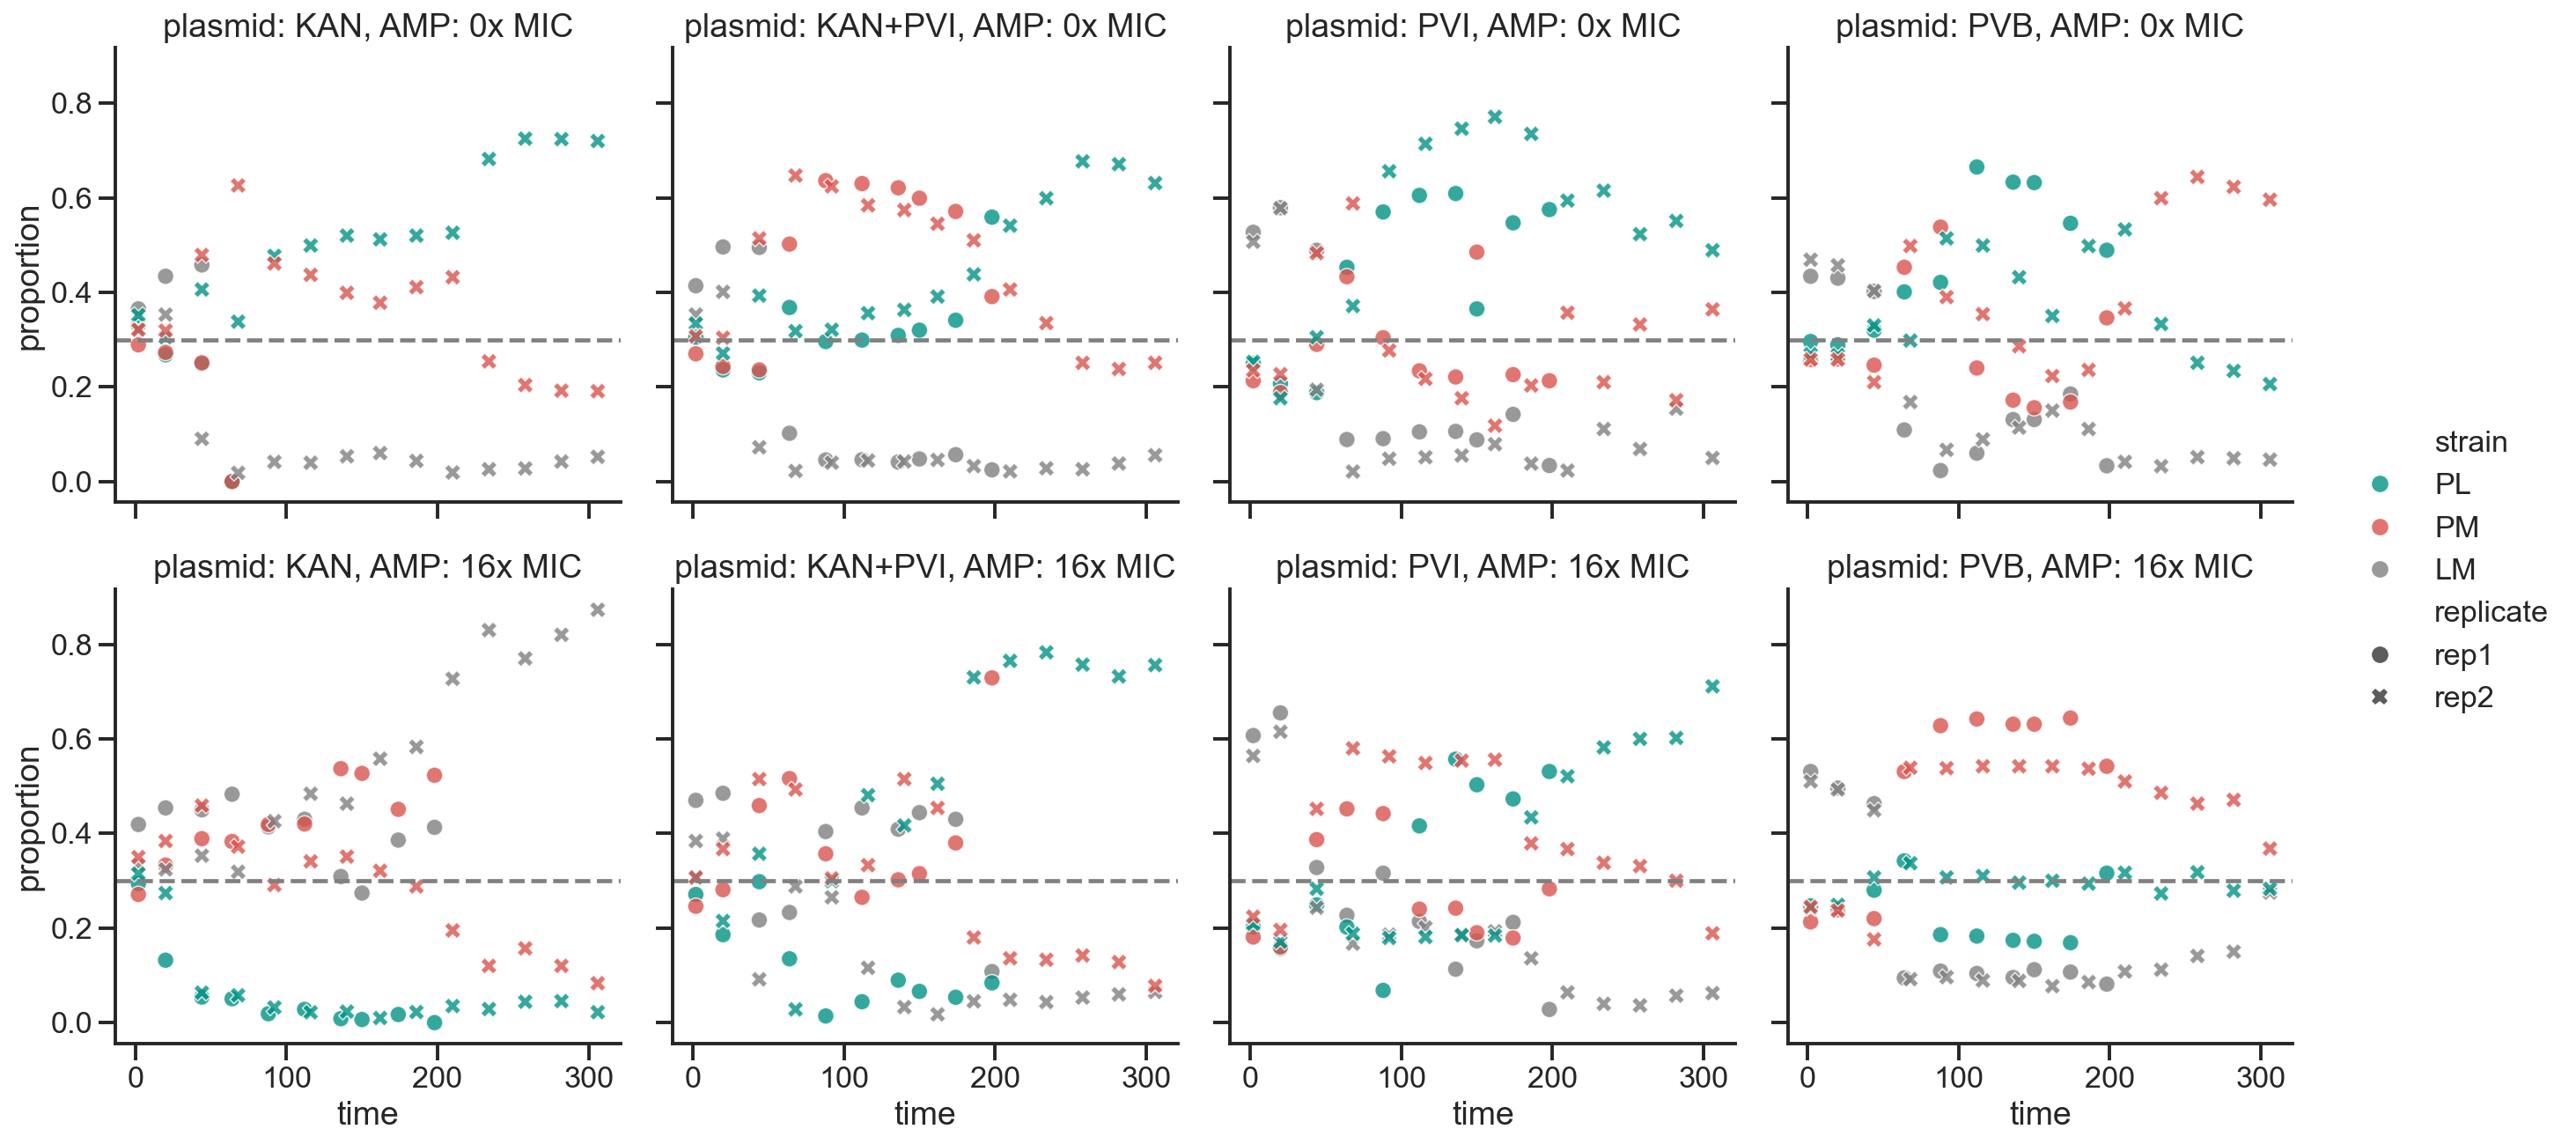

In [7]:
cp = sns.relplot(data=f,
                 x='time',
                 y='proportion',
                 hue='strain',
                 col='plasmid',
                 row='drug',
                 style='replicate',
                 height=4.5, aspect=1,
                 alpha=0.8,
                 palette=['xkcd:teal',
                          'xkcd:pale red',
                          'grey'],
                 hue_order=['PL', 'PM', 'LM'])

# cp.set(yscale='log')
cp.set_titles("plasmid: {col_name}, AMP: {row_name}x MIC")
cp.map(plt.axhline, y=.3, color='grey', linestyle='--');

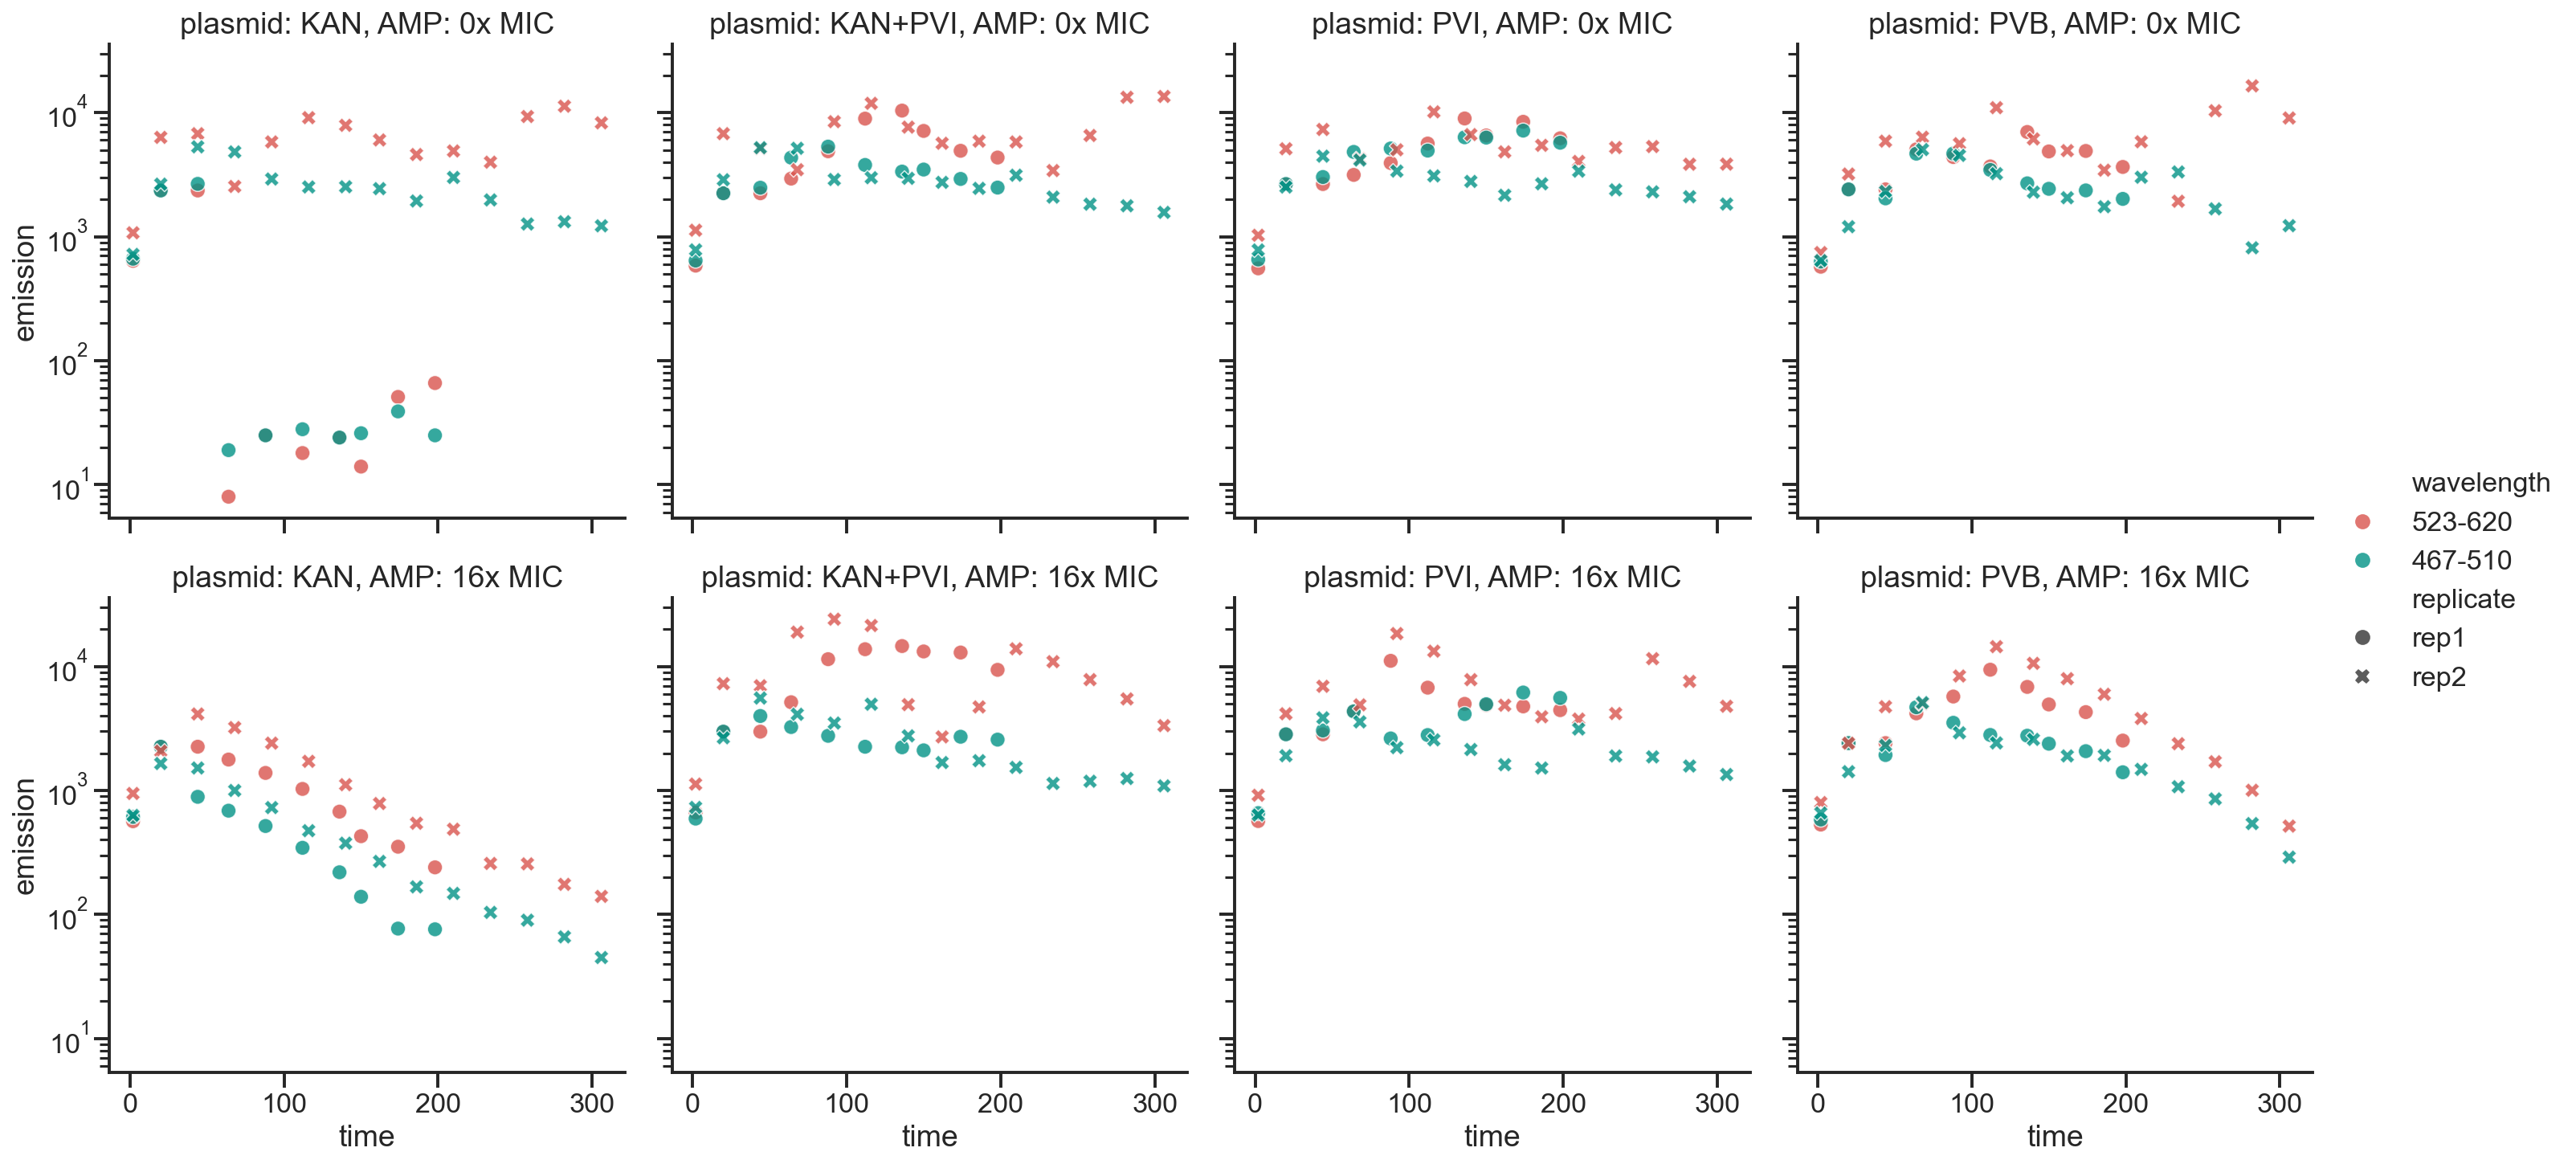

In [8]:
cp = sns.relplot(data=p,
                 x='time',
                 y='emission',
                 hue='wavelength',
                 col='plasmid',
                 row='drug',
                 style='replicate',
                 # col_wrap=4,
                 height=5, aspect=1,
                 alpha=0.8,
                 palette=['xkcd:pale red',
                          'xkcd:teal'])

cp.set(yscale='log', 
       # ylim=(10, 16000)
      )
cp.set_titles("plasmid: {col_name}, AMP: {row_name}x MIC");
# cp.map(plt.axhline, y=.3, color='grey', linestyle='--');